# Condition-Concatenated PCA Analysis

This notebook implements a PCA approach where each neuron is represented by concatenating its responses across six conditions (3 trial types × 2 directions):

1. **GO Left trials** (180°): aligned to go_cue, epoch [50, 300] ms
2. **GO Right trials** (0°): aligned to go_cue, epoch [50, 300] ms
3. **STOP Left trials** (180°): aligned to stop_cue, epoch [-50, 200] ms
4. **STOP Right trials** (0°): aligned to stop_cue, epoch [-50, 200] ms
5. **CONT Left trials** (180°): aligned to stop_cue, epoch [-50, 200] ms
6. **CONT Right trials** (0°): aligned to stop_cue, epoch [-50, 200] ms

## Methodology
- Only successful trials
- 1ms bins for PSTHs
- Neurons without data in all 6 conditions are excluded
- No pre-made normalization
- After concatenation: z-score each neuron (subtract mean, divide by std)
- TruncatedSVD for PCA
- Sort PCs by explained variance ratio
- Project trajectories on first 3 PCs

In [54]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from sklearn.decomposition import TruncatedSVD
import warnings
warnings.filterwarnings('ignore')

# Import project modules
import sys
sys.path.append('..')

import importlib
import cell_analysis
import session_class

# Reload modules to pick up any changes without restarting kernel
importlib.reload(cell_analysis)
importlib.reload(session_class)

from cell_analysis import Cell
from session_class import Session

# Plotting settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

print("✓ Imports loaded successfully!")
print("✓ Modules reloaded (cell_analysis, session_class)")

✓ Imports loaded successfully!
✓ Modules reloaded (cell_analysis, session_class)


## Configuration

In [55]:
# Analysis configuration
config = {
    # Data parameters
    'data_path': '../../data/unified_cell_trial_data/msn_fiona_cell_trial_data.pkl',
    
    # Time window parameters (ms)
    'go_epok': [50, 300],      # GO trials: aligned to go_cue
    'stop_epok': [-50, 200],   # STOP trials: aligned to stop_cue
    'cont_epok': [-50, 200],   # CONT trials: aligned to stop_cue
    'ssd_number': 1,         # SSD to use for STOP and CONT trials
    
    'bin_size': 1,             # 1ms bins for PSTHs
    'smooth_ker_size': 25,     # Smoothing kernel size (ms) for PSTH
    
    # PCA parameters
    'n_components': 5,        # Number of PCs to compute
    'n_pcs_to_plot': 3,        # Number of PCs to visualize
    
    # Trial filtering
    'success_only': True,      # Only use successful trials
    'min_cells_per_session': 15,
    'excluded_sessions': ['fi210628', 'fi210629', 'fi210704'],
    
    # Directions
    'directions': [0, 180],    # Right (0°), Left (180°)
}

# Compute derived parameters
config['go_n_bins'] = (config['go_epok'][1] - config['go_epok'][0]) // config['bin_size']
config['stop_n_bins'] = (config['stop_epok'][1] - config['stop_epok'][0]) // config['bin_size']
config['cont_n_bins'] = (config['cont_epok'][1] - config['cont_epok'][0]) // config['bin_size']

# 6 conditions: GO_L, GO_R, STOP_L, STOP_R, CONT_L, CONT_R
config['n_conditions'] = 6
config['total_n_bins'] = config['go_n_bins'] * 2 + config['stop_n_bins'] * 2 + config['cont_n_bins'] * 2

print("Configuration:")
print(f"  GO epoch: {config['go_epok']} ms → {config['go_n_bins']} bins × 2 directions = {config['go_n_bins'] * 2} bins")
print(f"  STOP epoch: {config['stop_epok']} ms → {config['stop_n_bins']} bins × 2 directions = {config['stop_n_bins'] * 2} bins")
print(f"  CONT epoch: {config['cont_epok']} ms → {config['cont_n_bins']} bins × 2 directions = {config['cont_n_bins'] * 2} bins")
print(f"  Total bins per neuron: {config['total_n_bins']} ({config['n_conditions']} conditions)")
print(f"  PCA components: {config['n_components']}")

Configuration:
  GO epoch: [50, 300] ms → 250 bins × 2 directions = 500 bins
  STOP epoch: [-50, 200] ms → 250 bins × 2 directions = 500 bins
  CONT epoch: [-50, 200] ms → 250 bins × 2 directions = 500 bins
  Total bins per neuron: 1500 (6 conditions)
  PCA components: 5


## 1. Load and Prepare Data

In [56]:
# Load data
print("Loading data...")
cell_df = pd.read_pickle(config['data_path'])
print(f"✓ Loaded {len(cell_df):,} cell-trial combinations")
print(f"  Sessions: {cell_df['trial_session'].nunique()}")
print(f"  Unique cells: {cell_df['cell_ID'].nunique()}")

Loading data...
✓ Loaded 770,705 cell-trial combinations
  Sessions: 60
  Unique cells: 1414


In [57]:
# Filter data
print("\nFiltering data...")

# Exclude sessions
cell_df = cell_df[~cell_df['trial_session'].isin(config['excluded_sessions'])]
print(f"  After excluding sessions: {len(cell_df):,} combinations")

# Filter to successful trials only
if config['success_only']:
    cell_df = cell_df[cell_df['trial_failed'] == False]
    print(f"  After filtering to successful trials: {len(cell_df):,} combinations")

# Get sessions with enough cells
session_cell_counts = cell_df.groupby('trial_session')['cell_ID'].nunique()
valid_sessions = session_cell_counts[session_cell_counts >= config['min_cells_per_session']].index.tolist()
cell_df = cell_df[cell_df['trial_session'].isin(valid_sessions)]
print(f"  Valid sessions (≥{config['min_cells_per_session']} cells): {len(valid_sessions)}")
print(f"  Final dataset: {len(cell_df):,} combinations, {cell_df['cell_ID'].nunique()} cells")


Filtering data...
  After excluding sessions: 770,705 combinations
  After filtering to successful trials: 654,569 combinations
  Valid sessions (≥15 cells): 31
  Final dataset: 576,686 combinations, 1213 cells


## 2. Define PSTH Extraction Function

We'll use the Cell class from `cell_analysis.py` to extract PSTHs for each condition.

In [58]:
def extract_neuron_psths_all_conditions(cell_id, cell_df, config):
    """
    Extract PSTHs for all 6 conditions (3 types × 2 directions) for a single neuron using Cell class.
    
    Parameters:
    -----------
    cell_id : int
        Cell identifier
    cell_df : DataFrame
        Full cell database
    config : dict
        Configuration parameters
    
    Returns:
    --------
    psths : dict
        Dictionary with keys: 'GO_L', 'GO_R', 'STOP_L', 'STOP_R', 'CONT_L', 'CONT_R'
        Each value is an array of firing rates
    has_all_conditions : bool
        True if neuron has data for all 6 conditions
    """
    # Get cell data and create Cell object
    cell_data = cell_df[cell_df['cell_ID'] == cell_id]
    cell = Cell(cell_data, verbose=False)
    
    psths = {}
    has_all_conditions = True
    
    # Extract for each trial type and direction combination
    for trial_type, epok, alignment in [('GO', config['go_epok'], 'go_cue'),
                                         ('STOP', config['stop_epok'], 'stop_cue'),
                                         ('CONT', config['cont_epok'], 'stop_cue')]:
        for direction in config['directions']:
            dir_label = 'L' if direction == 180 else 'R'
            key = f'{trial_type}_{dir_label}'
            
            _, firing_rate, n_trials = cell.calculate_psth(
                epok=epok,
                bin_size=config['bin_size'],
                alignment_point=alignment,
                trial_type=trial_type,
                direction=direction,
                ssd_number=config['ssd_number'],
                success_only=True,
                smooth=True,
                smooth_ker_size=config['smooth_ker_size'],
                delta=False,
                normalize_bins=False
            )
            
            # Check if we have data for this condition
            if firing_rate is None or n_trials == 0:
                has_all_conditions = False
                # Fill with zeros for now
                n_bins = config['go_n_bins'] if trial_type == 'GO' else \
                         config['stop_n_bins'] if trial_type == 'STOP' else \
                         config['cont_n_bins']
                firing_rate = np.zeros(n_bins)
            
            psths[key] = firing_rate
    
    return psths, has_all_conditions


print("✓ PSTH extraction function defined (using Cell class, all 6 conditions)")

✓ PSTH extraction function defined (using Cell class, all 6 conditions)


In [59]:
# Extract PSTHs for all neurons
print("Extracting PSTHs for all neurons using Cell class...")
print("Order: GO_L, GO_R, STOP_L, STOP_R, CONT_L, CONT_R\n")

cell_ids = cell_df['cell_ID'].unique()
n_features = config['total_n_bins']

# Temporary storage
neurons_data = []
neurons_ids = []
neurons_complete = []

# Store trial counts for quality control
trial_counts = {
    'GO_L': [], 'GO_R': [],
    'STOP_L': [], 'STOP_R': [],
    'CONT_L': [], 'CONT_R': []
}

for cell_id in tqdm(cell_ids, desc="Processing cells"):
    cell_data = cell_df[cell_df['cell_ID'] == cell_id]
    
    # Extract PSTHs for all 6 conditions
    psths, has_all_conditions = extract_neuron_psths_all_conditions(cell_id, cell_df, config)
    
    # Count trials for each condition
    for trial_type in ['GO', 'STOP', 'CONT']:
        for direction in config['directions']:
            dir_label = 'L' if direction == 180 else 'R'
            key = f'{trial_type}_{dir_label}'
            n_trials = len(cell_data[
                (cell_data['type'] == trial_type) & 
                (cell_data['dir'] == direction) & 
                (cell_data['trial_failed'] == False)
            ])
            trial_counts[key].append(n_trials)
    
    # Concatenate into single vector: GO_L, GO_R, STOP_L, STOP_R, CONT_L, CONT_R
    neuron_vector = np.concatenate([
        psths['GO_L'], psths['GO_R'],
        psths['STOP_L'], psths['STOP_R'],
        psths['CONT_L'], psths['CONT_R']
    ])
    
    neurons_data.append(neuron_vector)
    neurons_ids.append(cell_id)
    neurons_complete.append(has_all_conditions)

# Convert to arrays
X_raw_all = np.array(neurons_data)
all_cell_ids = np.array(neurons_ids)
complete_mask = np.array(neurons_complete)

# Filter to only neurons with all 6 conditions
X_raw = X_raw_all[complete_mask]
cell_ids = all_cell_ids[complete_mask]
n_cells = len(cell_ids)

print(f"\n✓ PSTH extraction complete")
print(f"  Total neurons processed: {len(all_cell_ids)}")
print(f"  Neurons with all 6 conditions: {n_cells}")
print(f"  Neurons excluded (missing conditions): {(~complete_mask).sum()}")
print(f"  Final data matrix shape: {X_raw.shape}")
print(f"  ({n_cells} neurons × {n_features} features)")
print(f"\nTrial counts per neuron (successful only, for neurons with all conditions):")
for key, counts in trial_counts.items():
    counts_complete = [counts[i] for i in range(len(counts)) if complete_mask[i]]
    if len(counts_complete) > 0:
        print(f"  {key:8s}: mean={np.mean(counts_complete):.1f}, min={np.min(counts_complete)}, max={np.max(counts_complete)}")

Extracting PSTHs for all neurons using Cell class...
Order: GO_L, GO_R, STOP_L, STOP_R, CONT_L, CONT_R



Processing cells:   0%|          | 0/1213 [00:00<?, ?it/s]

Processing cells: 100%|██████████| 1213/1213 [00:16<00:00, 72.13it/s]


✓ PSTH extraction complete
  Total neurons processed: 1213
  Neurons with all 6 conditions: 0
  Neurons excluded (missing conditions): 1213
  Final data matrix shape: (0, 1500)
  (0 neurons × 1500 features)

Trial counts per neuron (successful only, for neurons with all conditions):


In [60]:
X_raw.shape
plt.plot(X_raw[1,:250])

IndexError: index 1 is out of bounds for axis 0 with size 0

## 3. Normalize Data

For each neuron (row), subtract mean and divide by standard deviation (z-scoring).

In [ ]:
# Z-score normalization per neuron
print("Normalizing data (z-scoring per neuron)...")

X_normalized = np.zeros_like(X_raw)
normalization_stats = {'mean': [], 'std': []}

for i in range(n_cells):
    neuron_data = X_raw[i, :]
    mean = np.mean(neuron_data)
    std = np.std(neuron_data)
    
    normalization_stats['mean'].append(mean)
    normalization_stats['std'].append(std)
    
    # Z-score (handle zero std case)
    if std > 0:
        X_normalized[i, :] = (neuron_data - mean) / std
        X_normalized[i, :] = (neuron_data - mean) # / std
    else:
        X_normalized[i, :] = 0

print(f"✓ Normalization complete")
print(f"  Mean firing rate: {np.mean(normalization_stats['mean']):.2f} ± {np.std(normalization_stats['mean']):.2f} spikes/sec")
print(f"  Std firing rate: {np.mean(normalization_stats['std']):.2f} ± {np.std(normalization_stats['std']):.2f} spikes/sec")
print(f"  Normalized data: mean={np.mean(X_normalized):.6f}, std={np.std(X_normalized):.3f}")

Normalizing data (z-scoring per neuron)...
✓ Normalization complete
  Mean firing rate: 7.36 ± 8.21 spikes/sec
  Std firing rate: 1.92 ± 2.22 spikes/sec
  Normalized data: mean=-0.000000, std=2.934


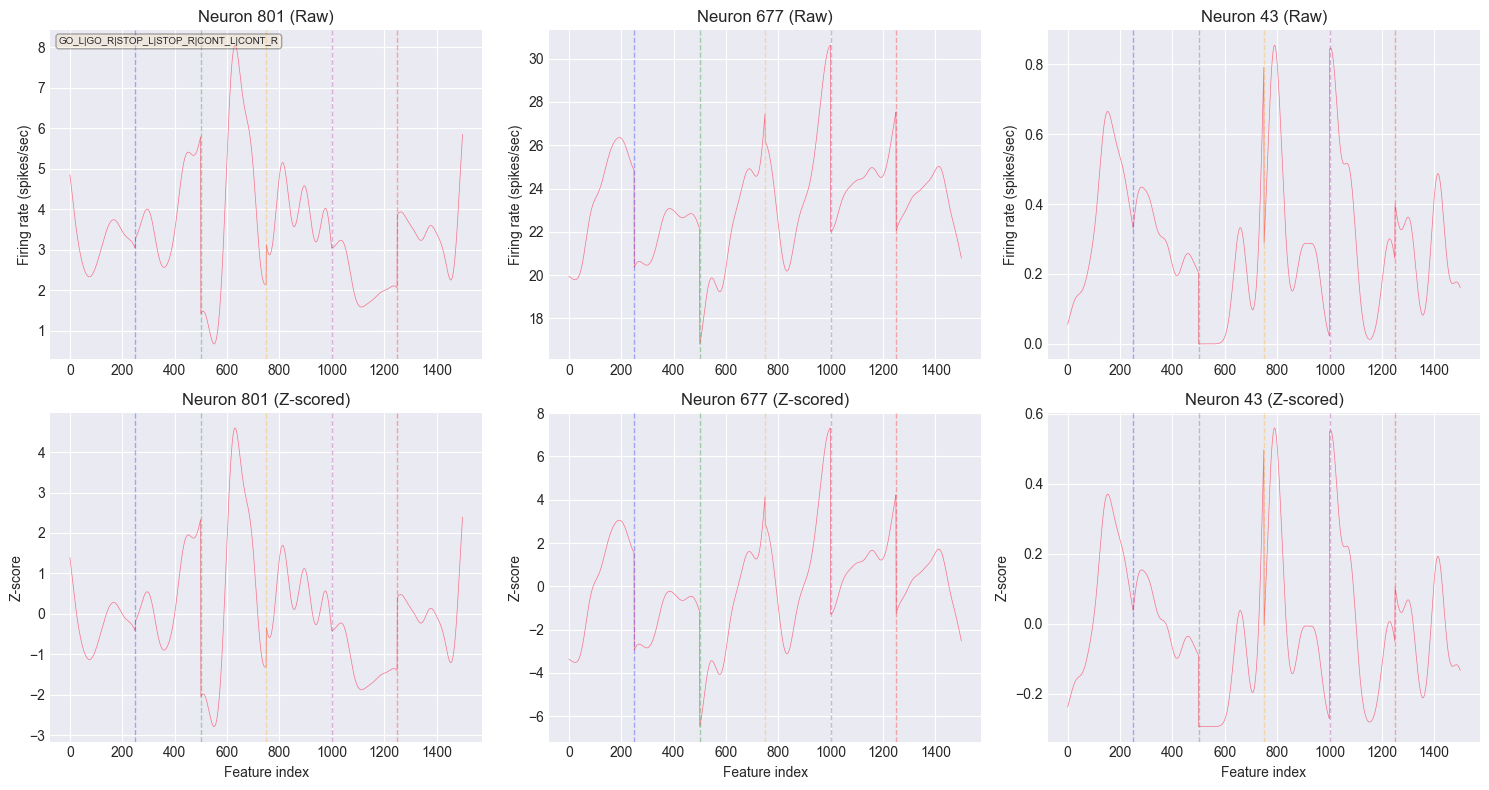


Condition boundaries (feature indices):
  GO_L: starts at index 0
  GO_R: starts at index 250
  STOP_L: starts at index 500
  STOP_R: starts at index 750
  CONT_L: starts at index 1000
  CONT_R: starts at index 1250


In [ ]:
# Visualize raw vs normalized data for a few neurons
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Select 3 random neurons
np.random.seed(42)
sample_neurons = np.random.choice(n_cells, min(3, n_cells), replace=False)

# Calculate boundaries for the 6 conditions
boundaries = {
    'GO_L': 0,
    'GO_R': config['go_n_bins'],
    'STOP_L': config['go_n_bins'] * 2,
    'STOP_R': config['go_n_bins'] * 2 + config['stop_n_bins'],
    'CONT_L': config['go_n_bins'] * 2 + config['stop_n_bins'] * 2,
    'CONT_R': config['go_n_bins'] * 2 + config['stop_n_bins'] * 2 + config['cont_n_bins']
}

for col, neuron_idx in enumerate(sample_neurons):
    # Raw data
    axes[0, col].plot(X_raw[neuron_idx, :], linewidth=0.5)
    axes[0, col].set_title(f'Neuron {neuron_idx} (Raw)')
    axes[0, col].set_ylabel('Firing rate (spikes/sec)')
    
    # Add vertical lines for condition boundaries
    for i, (label, pos) in enumerate(boundaries.items()):
        if pos > 0 and pos < config['total_n_bins']:
            color = ['red', 'blue', 'green', 'orange', 'purple'][i % 5]
            axes[0, col].axvline(pos, color=color, linestyle='--', alpha=0.3, linewidth=1)
    
    if col == 0:
        axes[0, col].text(0.02, 0.98, 'GO_L|GO_R|STOP_L|STOP_R|CONT_L|CONT_R', 
                         transform=axes[0, col].transAxes, fontsize=7, 
                         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    
    # Normalized data
    axes[1, col].plot(X_normalized[neuron_idx, :], linewidth=0.5)
    axes[1, col].set_title(f'Neuron {neuron_idx} (Z-scored)')
    axes[1, col].set_ylabel('Z-score')
    axes[1, col].set_xlabel('Feature index')
    
    # Add vertical lines for condition boundaries
    for i, (label, pos) in enumerate(boundaries.items()):
        if pos > 0 and pos < config['total_n_bins']:
            color = ['red', 'blue', 'green', 'orange', 'purple'][i % 5]
            axes[1, col].axvline(pos, color=color, linestyle='--', alpha=0.3, linewidth=1)

plt.tight_layout()
plt.show()

print(f"\nCondition boundaries (feature indices):")
for label, pos in boundaries.items():
    print(f"  {label}: starts at index {pos}")

## 4. Fit PCA using TruncatedSVD

Compute principal components and sort by explained variance ratio.

In [ ]:
# Fit TruncatedSVD
from sklearn.decomposition import PCA


print(f"Fitting TruncatedSVD with {config['n_components']} components...")

svd = TruncatedSVD(n_components=config['n_components'], random_state=42)
# svd = PCA(n_components=config['n_components'])
X_pca = svd.fit_transform(X_normalized)

print(f"\n✓ SVD fitted")
print(f"  Data shape after PCA: {X_pca.shape}")
print(f"  Explained variance ratios:")
for i, var in enumerate(svd.explained_variance_ratio_):
    print(f"    PC{i+1}: {var*100:.2f}%")
print(f"  Total variance explained: {svd.explained_variance_ratio_.sum()*100:.2f}%")

Fitting TruncatedSVD with 5 components...

✓ SVD fitted
  Data shape after PCA: (1212, 5)
  Explained variance ratios:
    PC1: 26.82%
    PC2: 25.29%
    PC3: 10.34%
    PC4: 5.38%
    PC5: 4.79%
  Total variance explained: 72.61%


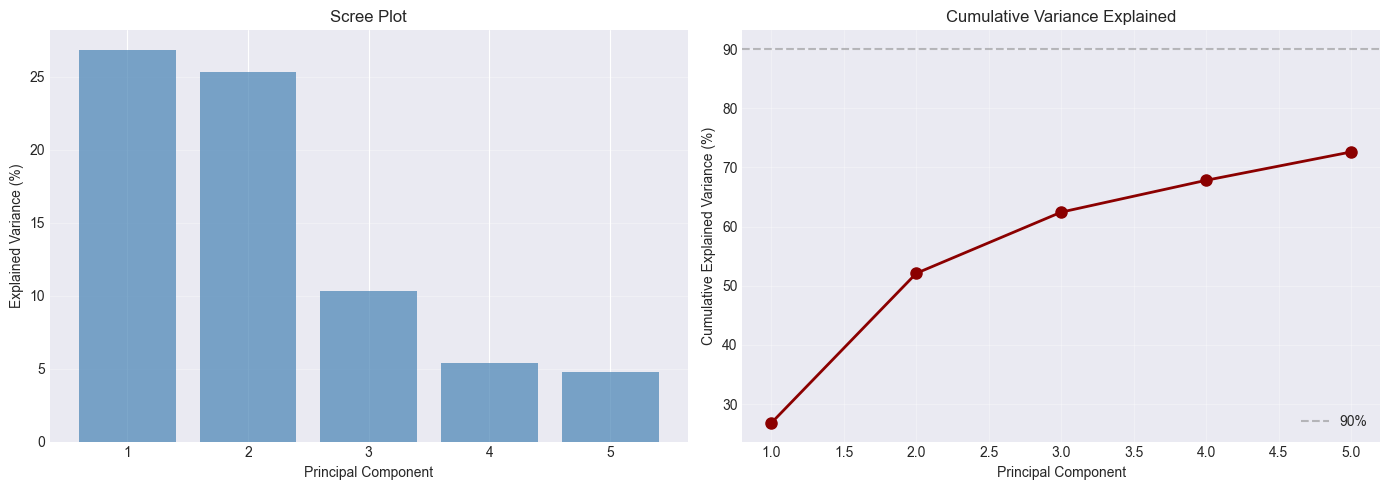

In [ ]:
# Visualize explained variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, config['n_components'] + 1), 
           svd.explained_variance_ratio_ * 100,
           alpha=0.7, color='steelblue')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Scree Plot')
axes[0].grid(axis='y', alpha=0.3)

# Cumulative variance
cumvar = np.cumsum(svd.explained_variance_ratio_) * 100
axes[1].plot(range(1, config['n_components'] + 1), cumvar, 
            marker='o', linewidth=2, markersize=8, color='darkred')
axes[1].axhline(90, color='gray', linestyle='--', alpha=0.5, label='90%')
axes[1].set_xlabel('Principal Component')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title('Cumulative Variance Explained')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Extract Condition Trajectories from PC Components

Each PC component is a 750-dimensional vector representing [GO|STOP|CONT].
We can split each PC into its condition-specific portions to visualize how that PC varies over time in each condition.

In [ ]:
# Extract condition-specific trajectories from PC components
print("Extracting condition trajectories from PC components...")

# PC components shape: (n_components, n_features=1500)
# Split into 6 conditions: GO_L, GO_R, STOP_L, STOP_R, CONT_L, CONT_R

# Calculate slice indices
idx_go_r = config['go_n_bins']
idx_stop_l = idx_go_r + config['go_n_bins']
idx_stop_r = idx_stop_l + config['stop_n_bins']
idx_cont_l = idx_stop_r + config['stop_n_bins']
idx_cont_r = idx_cont_l + config['cont_n_bins']

# Extract trajectories
go_left_trajectory = svd.components_[:, :idx_go_r]  # 0:250
go_right_trajectory = svd.components_[:, idx_go_r:idx_stop_l]  # 250:500
stop_left_trajectory = svd.components_[:, idx_stop_l:idx_stop_r]  # 500:750
stop_right_trajectory = svd.components_[:, idx_stop_r:idx_cont_l]  # 750:1000
cont_left_trajectory = svd.components_[:, idx_cont_l:idx_cont_r]  # 1000:1250
cont_right_trajectory = svd.components_[:, idx_cont_r:]  # 1250:1500

print(f"\n✓ Trajectories extracted from PC components")
print(f"  GO Left trajectory: {go_left_trajectory.shape}")
print(f"  GO Right trajectory: {go_right_trajectory.shape}")
print(f"  STOP Left trajectory: {stop_left_trajectory.shape}")
print(f"  STOP Right trajectory: {stop_right_trajectory.shape}")
print(f"  CONT Left trajectory: {cont_left_trajectory.shape}")
print(f"  CONT Right trajectory: {cont_right_trajectory.shape}")
print(f"\nInterpretation:")
print(f"  Each row is a PC, each column is a time bin")
print(f"  Values represent the loading/weight of that PC at that time point for each condition")

Extracting condition trajectories from PC components...

✓ Trajectories extracted from PC components
  GO Left trajectory: (5, 250)
  GO Right trajectory: (5, 250)
  STOP Left trajectory: (5, 250)
  STOP Right trajectory: (5, 250)
  CONT Left trajectory: (5, 250)
  CONT Right trajectory: (5, 250)

Interpretation:
  Each row is a PC, each column is a time bin
  Values represent the loading/weight of that PC at that time point for each condition


## 6. Visualize Trajectories in 3D PC Space

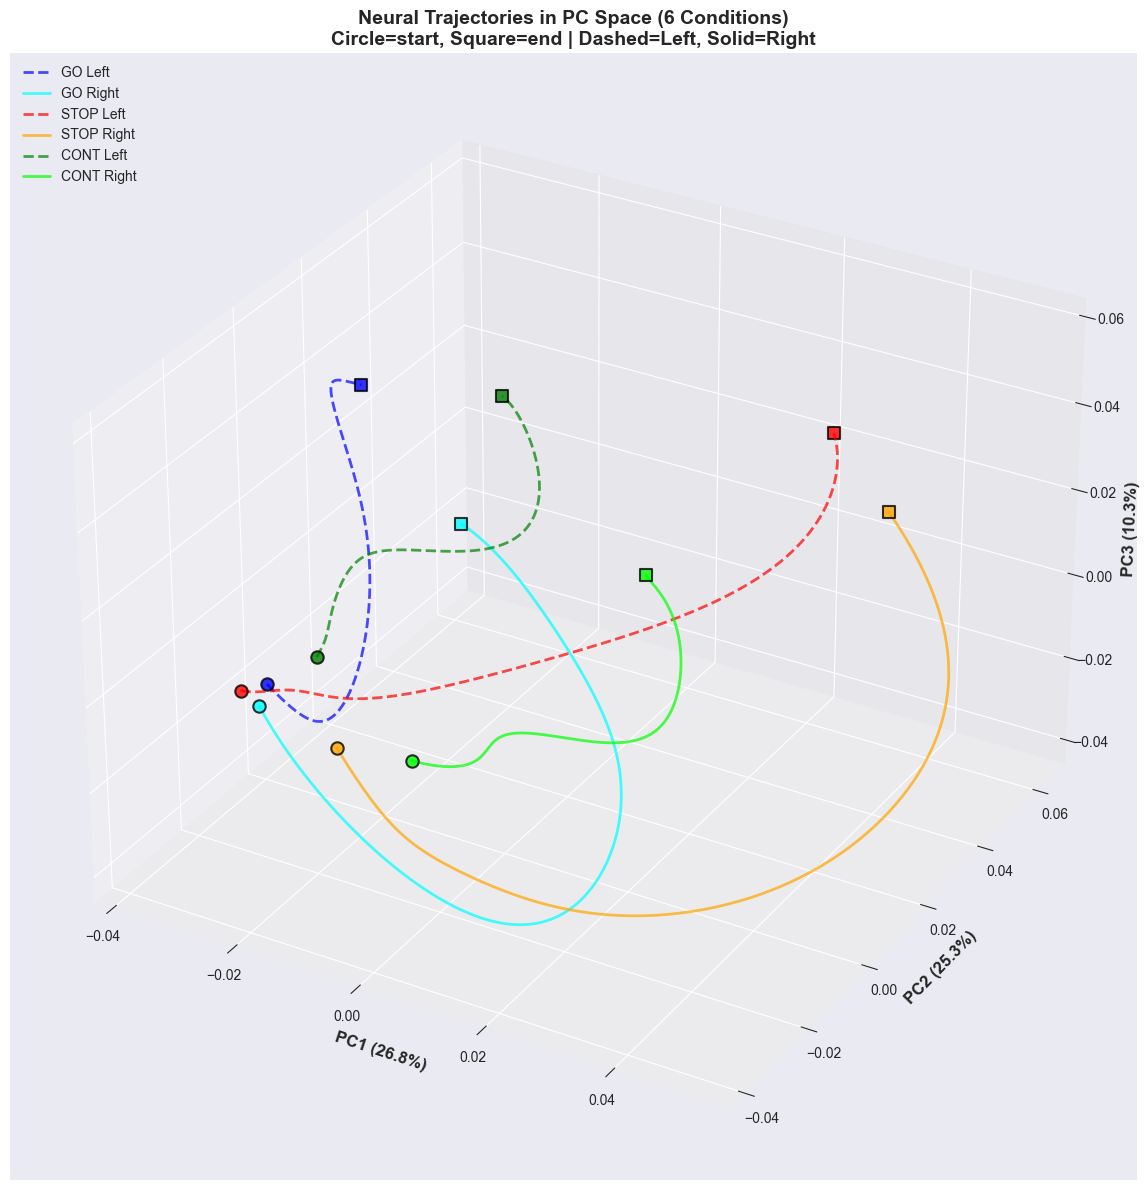

In [ ]:
# 3D trajectory plot
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111, projection='3d')

# Define colors and line styles for each condition
trajectories = [
    (go_left_trajectory, 'blue', 'GO Left', '--'),
    (go_right_trajectory, 'cyan', 'GO Right', '-'),
    (stop_left_trajectory, 'red', 'STOP Left', '--'),
    (stop_right_trajectory, 'orange', 'STOP Right', '-'),
    (cont_left_trajectory, 'green', 'CONT Left', '--'),
    (cont_right_trajectory, 'lime', 'CONT Right', '-'),
]

# Plot trajectories
for traj, color, label, linestyle in trajectories:
    ax.plot(traj[0, :], traj[1, :], traj[2, :], 
            label=label, color=color, linewidth=2, alpha=0.7, linestyle=linestyle)

# Mark start and end points
for traj, color, name, _ in trajectories:
    ax.scatter(traj[0, 0], traj[1, 0], traj[2, 0], 
              marker='o', s=80, color=color, edgecolors='black', linewidths=1.5, alpha=0.8)
    ax.scatter(traj[0, -1], traj[1, -1], traj[2, -1], 
              marker='s', s=80, color=color, edgecolors='black', linewidths=1.5, alpha=0.8)

# Labels
ax.set_xlabel(f'PC1 ({svd.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12, fontweight='bold')
ax.set_ylabel(f'PC2 ({svd.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12, fontweight='bold')
ax.set_zlabel(f'PC3 ({svd.explained_variance_ratio_[2]*100:.1f}%)', fontsize=12, fontweight='bold')
ax.set_title('Neural Trajectories in PC Space (6 Conditions)\nCircle=start, Square=end | Dashed=Left, Solid=Right', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')

plt.tight_layout()
plt.show()

## 7. 2D Projections

Visualize all pairwise PC projections.

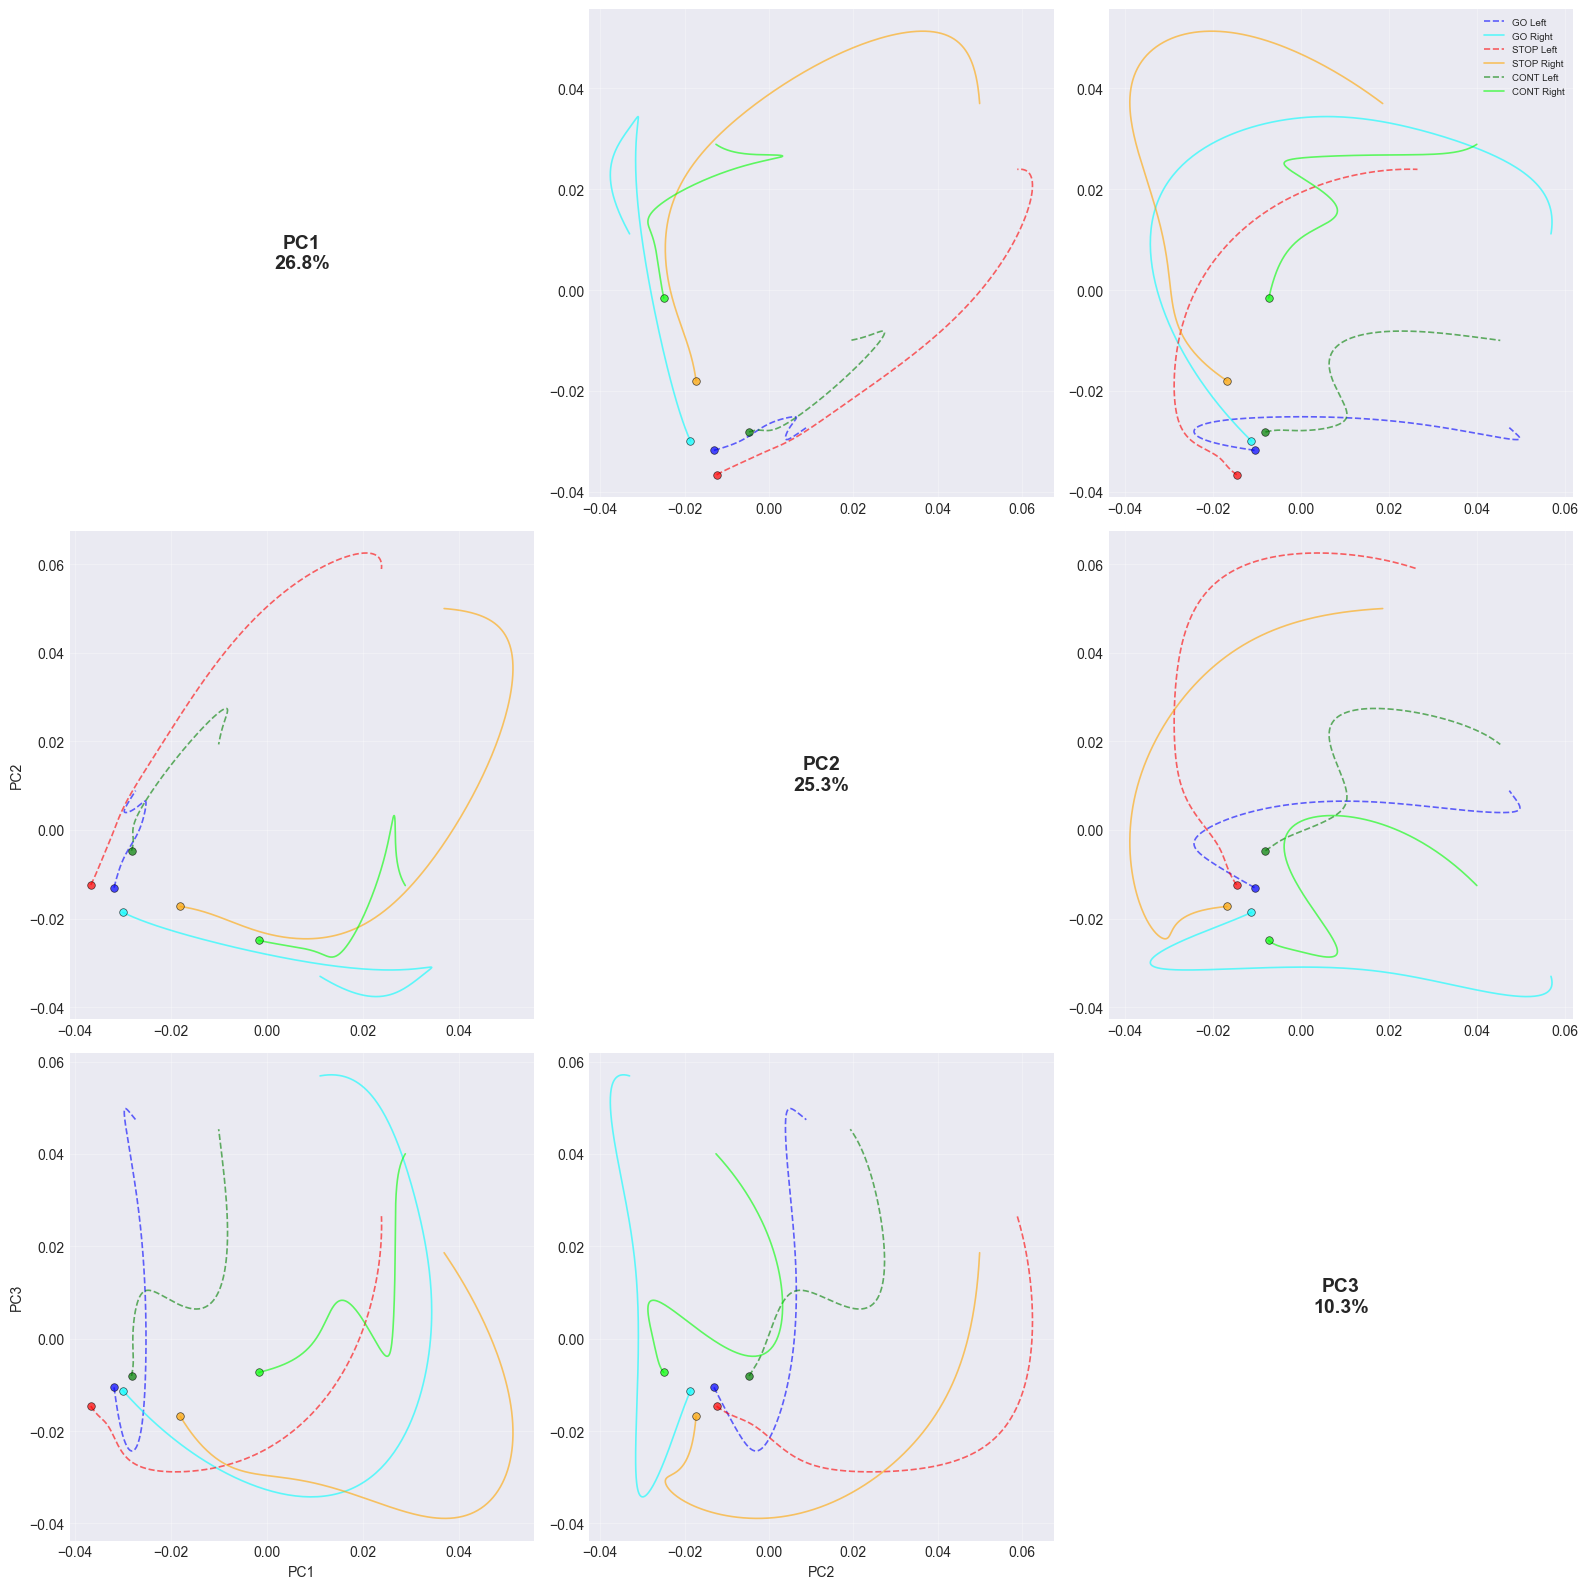

In [ ]:
# 2D projections grid
n_pcs = config['n_pcs_to_plot']
fig, axes = plt.subplots(n_pcs, n_pcs, figsize=(16, 16))

# Define trajectories with colors and styles
trajectories_2d = [
    (go_left_trajectory, 'blue', 'GO Left', '--'),
    (go_right_trajectory, 'cyan', 'GO Right', '-'),
    (stop_left_trajectory, 'red', 'STOP Left', '--'),
    (stop_right_trajectory, 'orange', 'STOP Right', '-'),
    (cont_left_trajectory, 'green', 'CONT Left', '--'),
    (cont_right_trajectory, 'lime', 'CONT Right', '-'),
]

for i in range(n_pcs):
    for j in range(n_pcs):
        ax = axes[i, j]
        
        if i == j:
            # Diagonal: show PC index and variance
            ax.text(0.5, 0.5, f'PC{i+1}\n{svd.explained_variance_ratio_[i]*100:.1f}%',
                   ha='center', va='center', fontsize=14, fontweight='bold')
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
            ax.axis('off')
        else:
            # Off-diagonal: plot trajectories
            for traj, color, label, linestyle in trajectories_2d:
                ax.plot(traj[j, :], traj[i, :], 
                       label=label, color=color, linewidth=1.2, alpha=0.6, linestyle=linestyle)
            
            # Mark start points
            for traj, color, _, _ in trajectories_2d:
                ax.scatter(traj[j, 0], traj[i, 0], 
                          marker='o', s=30, color=color, edgecolors='black', linewidths=0.5, zorder=5, alpha=0.7)
            
            ax.grid(alpha=0.3)
            
            # Labels only on edges
            if i == n_pcs - 1:
                ax.set_xlabel(f'PC{j+1}', fontsize=10)
            if j == 0:
                ax.set_ylabel(f'PC{i+1}', fontsize=10)
            
            # Legend only on top-right
            if i == 0 and j == n_pcs - 1:
                ax.legend(fontsize=7, loc='upper right', framealpha=0.8)

plt.tight_layout()
plt.show()

## 8. PC Time Series

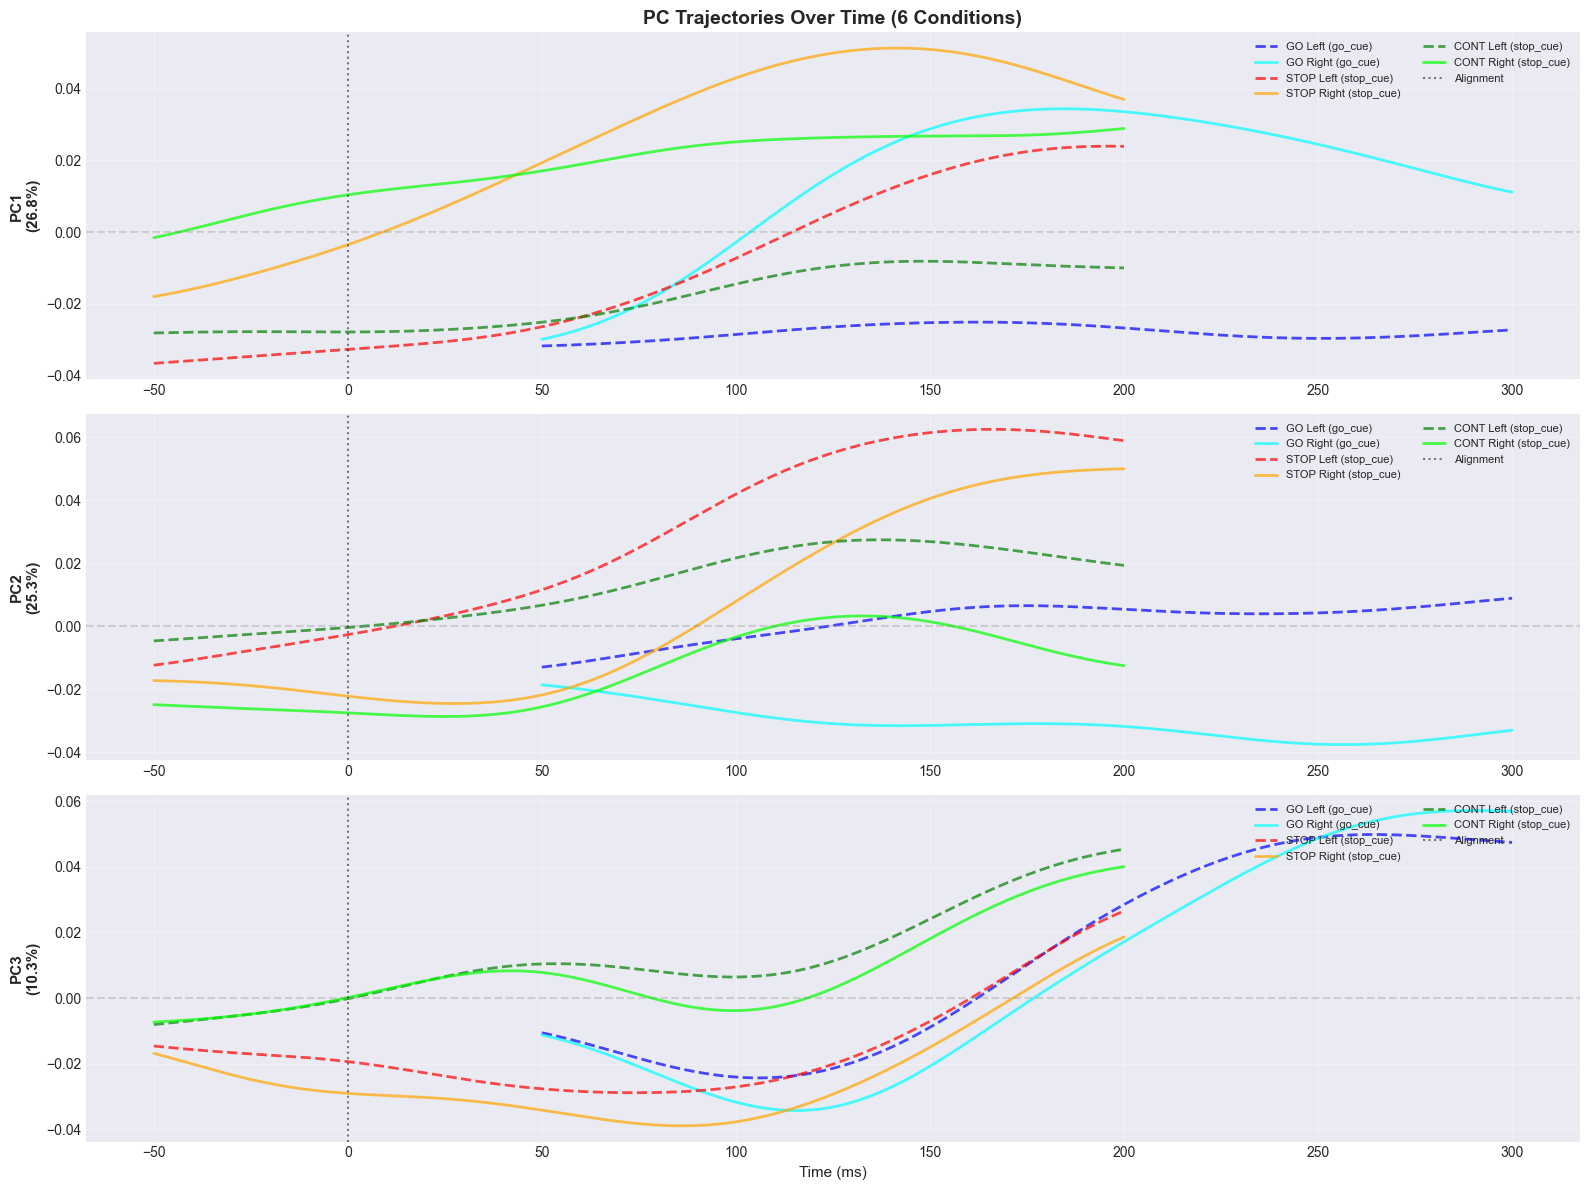

In [ ]:
# Plot PC time series
fig, axes = plt.subplots(config['n_pcs_to_plot'], 1, figsize=(16, 12))

# Time axes for each condition
go_time = np.linspace(config['go_epok'][0], config['go_epok'][1], config['go_n_bins'])
stop_time = np.linspace(config['stop_epok'][0], config['stop_epok'][1], config['stop_n_bins'])
cont_time = np.linspace(config['cont_epok'][0], config['cont_epok'][1], config['cont_n_bins'])

# Trajectories with time axes
trajectories_ts = [
    (go_left_trajectory, go_time, 'blue', 'GO Left (go_cue)', '--'),
    (go_right_trajectory, go_time, 'cyan', 'GO Right (go_cue)', '-'),
    (stop_left_trajectory, stop_time, 'red', 'STOP Left (stop_cue)', '--'),
    (stop_right_trajectory, stop_time, 'orange', 'STOP Right (stop_cue)', '-'),
    (cont_left_trajectory, cont_time, 'green', 'CONT Left (stop_cue)', '--'),
    (cont_right_trajectory, cont_time, 'lime', 'CONT Right (stop_cue)', '-'),
]

for i in range(config['n_pcs_to_plot']):
    ax = axes[i]
    
    # Plot trajectories
    for traj, time_axis, color, label, linestyle in trajectories_ts:
        ax.plot(time_axis, traj[i, :], label=label, 
               color=color, linewidth=2, alpha=0.7, linestyle=linestyle)
    
    # Formatting
    ax.axhline(0, color='gray', linestyle='--', alpha=0.3)
    ax.axvline(0, color='black', linestyle=':', alpha=0.5, linewidth=1.5, label='Alignment')
    ax.set_ylabel(f'PC{i+1}\n({svd.explained_variance_ratio_[i]*100:.1f}%)', fontsize=11, fontweight='bold')
    ax.legend(loc='upper right', fontsize=8, ncol=2, framealpha=0.9)
    ax.grid(alpha=0.3)
    
    if i == 0:
        ax.set_title('PC Trajectories Over Time (6 Conditions)', fontsize=14, fontweight='bold')
    if i == config['n_pcs_to_plot'] - 1:
        ax.set_xlabel('Time (ms)', fontsize=11)

plt.tight_layout()
plt.show()

## 9. Summary and Save Results

In [ ]:
# Print summary
print("=" * 80)
print("CONDITION-CONCATENATED PCA ANALYSIS SUMMARY")
print("=" * 80)
print(f"\nDataset:")
print(f"  Neurons analyzed: {n_cells}")
print(f"  Valid sessions: {len(valid_sessions)}")
print(f"  Features per neuron: {n_features}")
print(f"    - GO Left epoch {config['go_epok']}: {config['go_n_bins']} bins")
print(f"    - GO Right epoch {config['go_epok']}: {config['go_n_bins']} bins")
print(f"    - STOP Left epoch {config['stop_epok']}: {config['stop_n_bins']} bins")
print(f"    - STOP Right epoch {config['stop_epok']}: {config['stop_n_bins']} bins")
print(f"    - CONT Left epoch {config['cont_epok']}: {config['cont_n_bins']} bins")
print(f"    - CONT Right epoch {config['cont_epok']}: {config['cont_n_bins']} bins")
print(f"  Total: {config['n_conditions']} conditions × {config['go_n_bins']} bins each")
print(f"\nPCA:")
print(f"  Method: TruncatedSVD")
print(f"  Components: {config['n_components']}")
print(f"  Total variance explained: {svd.explained_variance_ratio_.sum()*100:.2f}%")
print(f"  Top 3 PCs: {svd.explained_variance_ratio_[:3].sum()*100:.2f}%")
print("=" * 80)

CONDITION-CONCATENATED PCA ANALYSIS SUMMARY

Dataset:
  Neurons analyzed: 1212
  Valid sessions: 31
  Features per neuron: 1500
    - GO Left epoch [50, 300]: 250 bins
    - GO Right epoch [50, 300]: 250 bins
    - STOP Left epoch [-50, 200]: 250 bins
    - STOP Right epoch [-50, 200]: 250 bins
    - CONT Left epoch [-50, 200]: 250 bins
    - CONT Right epoch [-50, 200]: 250 bins
  Total: 6 conditions × 250 bins each

PCA:
  Method: TruncatedSVD
  Components: 5
  Total variance explained: 72.61%
  Top 3 PCs: 62.44%


In [ ]:
# Save results
output_dir = Path('../../data/condition_concatenated_pca')
output_dir.mkdir(parents=True, exist_ok=True)

# Save data matrices
np.save(output_dir / 'X_raw.npy', X_raw)
np.save(output_dir / 'X_normalized.npy', X_normalized)

# Save PCA model components
np.save(output_dir / 'pca_components.npy', svd.components_)
np.save(output_dir / 'explained_variance_ratio.npy', svd.explained_variance_ratio_)

# Save all 6 trajectories
np.save(output_dir / 'go_left_trajectory.npy', go_left_trajectory)
np.save(output_dir / 'go_right_trajectory.npy', go_right_trajectory)
np.save(output_dir / 'stop_left_trajectory.npy', stop_left_trajectory)
np.save(output_dir / 'stop_right_trajectory.npy', stop_right_trajectory)
np.save(output_dir / 'cont_left_trajectory.npy', cont_left_trajectory)
np.save(output_dir / 'cont_right_trajectory.npy', cont_right_trajectory)

# Save cell IDs
np.save(output_dir / 'cell_ids.npy', cell_ids)

# Save metadata
import json
metadata = {
    'n_cells': int(n_cells),
    'n_features': int(n_features),
    'n_conditions': config['n_conditions'],
    'valid_sessions': valid_sessions,
    'config': {k: v if not isinstance(v, np.ndarray) else v.tolist() 
              for k, v in config.items()},
    'trial_counts': {k: {'mean': float(np.mean([counts[i] for i in range(len(counts)) if complete_mask[i]])), 
                         'min': int(np.min([counts[i] for i in range(len(counts)) if complete_mask[i]])), 
                         'max': int(np.max([counts[i] for i in range(len(counts)) if complete_mask[i]]))}
                    for k, counts in trial_counts.items()},
    'variance_explained_top3': float(svd.explained_variance_ratio_[:3].sum() * 100),
    'variance_explained_total': float(svd.explained_variance_ratio_.sum() * 100),
    'conditions_order': ['GO_L', 'GO_R', 'STOP_L', 'STOP_R', 'CONT_L', 'CONT_R'],
    'condition_indices': {
        'GO_L': [0, config['go_n_bins']],
        'GO_R': [config['go_n_bins'], config['go_n_bins']*2],
        'STOP_L': [config['go_n_bins']*2, config['go_n_bins']*2 + config['stop_n_bins']],
        'STOP_R': [config['go_n_bins']*2 + config['stop_n_bins'], config['go_n_bins']*2 + config['stop_n_bins']*2],
        'CONT_L': [config['go_n_bins']*2 + config['stop_n_bins']*2, 
                   config['go_n_bins']*2 + config['stop_n_bins']*2 + config['cont_n_bins']],
        'CONT_R': [config['go_n_bins']*2 + config['stop_n_bins']*2 + config['cont_n_bins'], 
                   config['total_n_bins']]
    }
}

with open(output_dir / 'metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"✓ Results saved to: {output_dir}")
print(f"\nSaved files:")
print(f"  - X_raw.npy, X_normalized.npy")
print(f"  - pca_components.npy, explained_variance_ratio.npy")
print(f"  - 6 trajectory files (go_left_trajectory.npy, ...)")
print(f"  - cell_ids.npy")
print(f"  - metadata.json")

✓ Results saved to: ../../data/condition_concatenated_pca

Saved files:
  - X_raw.npy, X_normalized.npy
  - pca_components.npy, explained_variance_ratio.npy
  - 6 trajectory files (go_left_trajectory.npy, ...)
  - cell_ids.npy
  - metadata.json
